Searching Kaggle input directories...

Train directories found:
   /kaggle/input/competitions/rogii-wellbore-geology-prediction/train

Using:
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train

Found 773 horizontal well files

Example files:
   /kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
   /kaggle/input/competitions/rogii-wellbore-geology-prediction/train/5d11dfb5__horizontal_well.csv
   /kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b881d27e__horizontal_well.csv
   /kaggle/input/competitions/rogii-wellbore-geology-prediction/train/122bd617__horizontal_well.csv
   /kaggle/input/competitions/rogii-wellbore-geology-prediction/train/ef04658e__horizontal_well.csv
Processing b0f53bf4 (4,202 rows)
Processing 5d11dfb5 (7,643 rows)
Processing b881d27e (5,442 rows)
Processing 122bd617 (6,408 rows)
Processing ef04658e (5,664 rows)
Processing 4ddde4c1 (6,417 rows)
Processing 46a7190b (5,646 rows)
Processing 

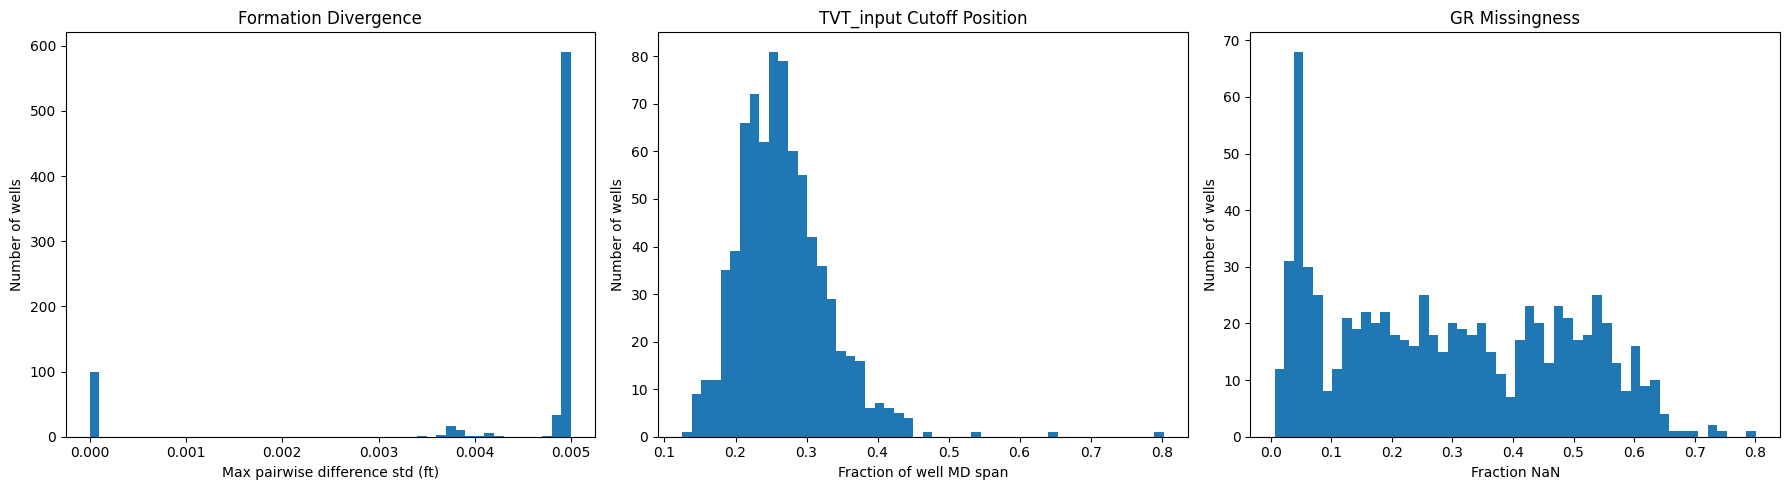


Plot saved to:
/kaggle/working/stage1_diagnostics.png

TOP 5% MOST DIVERGENT WELLS
Threshold: 0.01 ft

      well_id  max_pairwise_diff_std
40   da2d4d7c               0.005001
0    b0f53bf4               0.005001
168  8b95d6d1               0.005001
424  2ab29395               0.005001
240  f439a621               0.005001
504  d07aed8f               0.005000
177  f074d277               0.005000
377  2b547943               0.005000
528  a2e8e7f6               0.005000
389  511e1db0               0.005000
83   3a824aa7               0.005000
555  463c38f2               0.005000
33   9283ae69               0.005000
221  c9e6734f               0.005000
530  b4f37e6e               0.005000
91   153552f5               0.005000
525  9efc812e               0.005000
32   d0a43760               0.005000
343  c47e0767               0.005000
764  a85bb86f               0.005000

Stage 1 diagnostics complete.


In [9]:
"""
STAGE 1 DIAGNOSTICS — physical hypothesis checks, not modeling.

Q1. Do the 6 formation-top columns move in lockstep within each well?
Q2. How consistent is the TVT_input cutoff point across wells?
Q3. How much does GR missingness vary well to well?
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. FIND THE TRAIN DIRECTORY AUTOMATICALLY
# ============================================================

print("Searching Kaggle input directories...\n")

train_dirs = []

for root, dirs, files in os.walk("/kaggle/input"):
    if os.path.basename(root).lower() == "train":
        train_dirs.append(root)

print("Train directories found:")

for d in train_dirs:
    print("  ", d)

if not train_dirs:
    raise FileNotFoundError(
        "Could not find a 'train' directory under /kaggle/input"
    )

TRAIN_DIR = train_dirs[0]

print("\nUsing:")
print(TRAIN_DIR)


# ============================================================
# 2. FIND HORIZONTAL WELL FILES
# ============================================================

hw_files = glob.glob(
    os.path.join(
        TRAIN_DIR,
        "**",
        "*horizontal_well*.csv"
    ),
    recursive=True
)

# Also try the exact original naming pattern
if not hw_files:
    hw_files = glob.glob(
        os.path.join(
            TRAIN_DIR,
            "**",
            "*__horizontal_well.csv"
        ),
        recursive=True
    )

print(f"\nFound {len(hw_files)} horizontal well files")


# ============================================================
# 3. SAFETY CHECK
# ============================================================

if len(hw_files) == 0:

    print("\nNo horizontal well files were found.")

    print("\nCSV files found inside train:")

    csv_files = glob.glob(
        os.path.join(
            TRAIN_DIR,
            "**",
            "*.csv"
        ),
        recursive=True
    )

    for f in csv_files[:30]:
        print("  ", f)

    raise FileNotFoundError(
        "\nThe file naming pattern is different from expected. "
        "Check the filenames printed above."
    )


print("\nExample files:")

for f in hw_files[:5]:
    print("  ", f)


# ============================================================
# 4. CONFIGURATION
# ============================================================

FORMATION_COLS = [
    "ANCC",
    "ASTNU",
    "ASTNL",
    "EGFDU",
    "EGFDL",
    "BUDA"
]


# ============================================================
# 5. RUN DIAGNOSTICS
# ============================================================

rows = []

for fp in hw_files:

    well_id = os.path.basename(fp).split("__")[0]

    hw = pd.read_csv(fp)

    print(
        f"Processing {well_id} "
        f"({len(hw):,} rows)"
    )


    # --------------------------------------------------------
    # Check required columns
    # --------------------------------------------------------

    required_cols = (
        FORMATION_COLS
        + ["TVT_input", "MD", "GR"]
    )

    missing_cols = [
        c for c in required_cols
        if c not in hw.columns
    ]

    if missing_cols:

        print(
            f"  WARNING: missing columns: "
            f"{missing_cols}"
        )

        continue


    # ========================================================
    # Q1 — FORMATION LOCKSTEP / DIVERGENCE
    # ========================================================

    stds = hw[FORMATION_COLS].std()

    lockstep_std_spread = (
        stds.max() - stds.min()
    )

    diff_stds = []

    for i in range(len(FORMATION_COLS)):

        for j in range(i + 1, len(FORMATION_COLS)):

            d = (
                hw[FORMATION_COLS[i]]
                - hw[FORMATION_COLS[j]]
            )

            diff_stds.append(
                d.std()
            )

    max_pairwise_diff_std = max(
        diff_stds
    )


    # ========================================================
    # Q2 — TVT_INPUT CUTOFF
    # ========================================================

    n_rows = len(hw)

    tvt_missing = hw["TVT_input"].isna()

    if tvt_missing.any():

        # Actual positional index of first NaN
        first_nan_position = np.flatnonzero(
            tvt_missing.values
        )[0]

        cutoff_frac_by_row = (
            first_nan_position / n_rows
        )

        md_at_cutoff = hw.iloc[
            first_nan_position
        ]["MD"]

        md_min = hw["MD"].min()
        md_max = hw["MD"].max()

        md_span = md_max - md_min

        if md_span > 0:

            cutoff_frac_by_md = (
                (md_at_cutoff - md_min)
                / md_span
            )

        else:

            cutoff_frac_by_md = np.nan

    else:

        cutoff_frac_by_row = np.nan
        cutoff_frac_by_md = np.nan


    # ========================================================
    # Q3 — GR MISSINGNESS
    # ========================================================

    gr_missing_frac = (
        hw["GR"].isna().mean()
    )


    # ========================================================
    # SAVE RESULTS
    # ========================================================

    rows.append({
        "well_id": well_id,
        "n_rows": n_rows,

        "lockstep_std_spread":
            lockstep_std_spread,

        "max_pairwise_diff_std":
            max_pairwise_diff_std,

        "cutoff_frac_by_row":
            cutoff_frac_by_row,

        "cutoff_frac_by_md":
            cutoff_frac_by_md,

        "gr_missing_frac":
            gr_missing_frac
    })


# ============================================================
# 6. CREATE DIAGNOSTICS DATAFRAME
# ============================================================

diag = pd.DataFrame(rows)

if diag.empty:

    raise ValueError(
        "No valid horizontal wells were processed. "
        "Check the file structure and required columns."
    )


print("\n" + "=" * 60)
print("STAGE 1 DIAGNOSTICS SUMMARY")
print("=" * 60)

print(diag.describe())


# ============================================================
# 7. SAVE CSV
# ============================================================

output_csv = (
    "/kaggle/working/stage1_diagnostics.csv"
)

diag.to_csv(
    output_csv,
    index=False
)

print(
    f"\nDiagnostics saved to:\n{output_csv}"
)


# ============================================================
# 8. PLOTS
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


# ------------------------------------------------------------
# Q1
# ------------------------------------------------------------

axes[0].hist(
    diag["max_pairwise_diff_std"].dropna(),
    bins=50
)

axes[0].set_title(
    "Formation Divergence"
)

axes[0].set_xlabel(
    "Max pairwise difference std (ft)"
)

axes[0].set_ylabel(
    "Number of wells"
)


# ------------------------------------------------------------
# Q2
# ------------------------------------------------------------

axes[1].hist(
    diag["cutoff_frac_by_md"].dropna(),
    bins=50
)

axes[1].set_title(
    "TVT_input Cutoff Position"
)

axes[1].set_xlabel(
    "Fraction of well MD span"
)

axes[1].set_ylabel(
    "Number of wells"
)


# ------------------------------------------------------------
# Q3
# ------------------------------------------------------------

axes[2].hist(
    diag["gr_missing_frac"].dropna(),
    bins=50
)

axes[2].set_title(
    "GR Missingness"
)

axes[2].set_xlabel(
    "Fraction NaN"
)

axes[2].set_ylabel(
    "Number of wells"
)


plt.tight_layout()


output_png = (
    "/kaggle/working/stage1_diagnostics.png"
)

plt.savefig(
    output_png,
    dpi=120,
    bbox_inches="tight"
)

plt.show()

print(
    f"\nPlot saved to:\n{output_png}"
)


# ============================================================
# 9. FLAG TOP 5% FAULT-LIKE WELLS
# ============================================================

threshold = diag[
    "max_pairwise_diff_std"
].quantile(0.95)

suspects = (
    diag[
        diag["max_pairwise_diff_std"]
        >= threshold
    ]
    .sort_values(
        "max_pairwise_diff_std",
        ascending=False
    )
)


print("\n" + "=" * 60)
print("TOP 5% MOST DIVERGENT WELLS")
print("=" * 60)

print(
    f"Threshold: {threshold:.2f} ft\n"
)

print(
    suspects[
        [
            "well_id",
            "max_pairwise_diff_std"
        ]
    ].head(20)
)


print("\nStage 1 diagnostics complete.")

Pearson r  (GR missing % vs cutoff position): -0.110
Spearman r (GR missing % vs cutoff position): -0.090


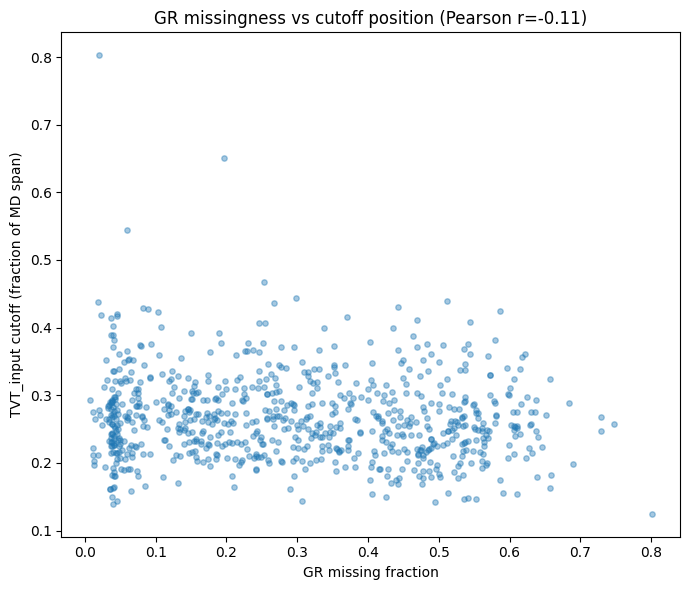


Wells with above-median GR missing AND below-median cutoff
(least labeled signal + shortest labeled run-in): 217 / 773 (28.1%)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
 
sub = diag.dropna(subset=["gr_missing_frac", "cutoff_frac_by_md"])
 
pearson_r = np.corrcoef(sub["gr_missing_frac"], sub["cutoff_frac_by_md"])[0, 1]
spearman_r = sub["gr_missing_frac"].corr(sub["cutoff_frac_by_md"], method="spearman")
 
print(f"Pearson r  (GR missing % vs cutoff position): {pearson_r:.3f}")
print(f"Spearman r (GR missing % vs cutoff position): {spearman_r:.3f}")
 
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sub["gr_missing_frac"], sub["cutoff_frac_by_md"], alpha=0.4, s=15)
ax.set_xlabel("GR missing fraction")
ax.set_ylabel("TVT_input cutoff (fraction of MD span)")
ax.set_title(f"GR missingness vs cutoff position (Pearson r={pearson_r:.2f})")
plt.tight_layout()
plt.savefig("/kaggle/working/gr_vs_cutoff.png", dpi=120, bbox_inches="tight")
plt.show()
 
# Split into quadrants to see if "double-hard" wells are common
median_gr_miss = sub["gr_missing_frac"].median()
median_cutoff = sub["cutoff_frac_by_md"].median()
 
hard_hard = sub[(sub["gr_missing_frac"] > median_gr_miss) & (sub["cutoff_frac_by_md"] < median_cutoff)]
print(f"\nWells with above-median GR missing AND below-median cutoff")
print(f"(least labeled signal + shortest labeled run-in): {len(hard_hard)} / {len(sub)} "
      f"({100*len(hard_hard)/len(sub):.1f}%)")


Found 773 typewell files
     well_id  critical_window_ft
0   14fee784                  20
1   08fecf00                  20
2   d5df0ff5                  25
3   cf50c9d1                  20
4   b4f37e6e                  20
5   d6dd7330                  25
6   1944513c                  30
7   8255c867                  20
8   16e4a047                  30
9   43c7f85a                  25
10  81fc01c6                  30
11  c99f9fae                  20
12  8b5be31b                  20
13  4654e7de                  20
14  c2c4db09                  20
15  633774dc                  25
16  0c1b160c                  30
17  060ab2b8                  25
18  a08d9e63                  25
19  ab94878e                  20
20  052d64df                  20
21  8cc21f01                  30
22  cc8a1d57                  40
23  9d072e4c                  30
24  a7744f5b                  20
25  44441e54                  30
26  999daf80                  25
27  01869cd4                  20
28  2bff06cf      

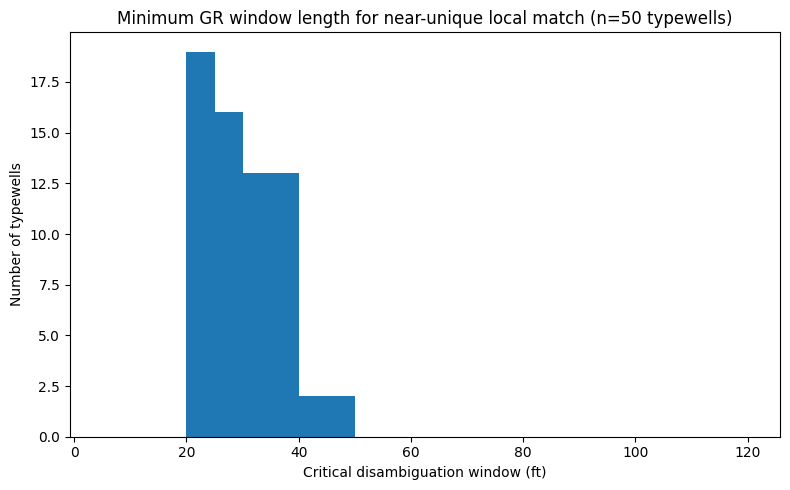

In [11]:
"""
STAGE 2 DIAGNOSTIC — locality/receptive-field question.

For each typewell, find the smallest GR window length (in ft) at which
local GR shape becomes ~unique across the typewell (little/no ambiguous
near-duplicate elsewhere). This is the "critical disambiguation window" —
the minimum context length a model would need to reliably localize
position from GR shape alone.

We do this across a SAMPLE of typewells (not all 773, for speed) to see
whether the ~20-30ft threshold found on one example well is stable or
highly variable across the dataset.
"""

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRAIN_DIR = "/kaggle/input/competitions/rogii-wellbore-geology-prediction/train"
N_SAMPLE_WELLS = 50
WINDOW_SIZES_FT = [5, 10, 15, 20, 25, 30, 40, 50, 60, 80, 100, 120]
AMBIGUOUS_CORR_THRESHOLD = 0.85
AMBIGUOUS_FRACTION_THRESHOLD = 0.05  # "essentially unique" = <=5% of windows have a near-dup

rng = np.random.default_rng(0)

tw_files = sorted(glob.glob(os.path.join(TRAIN_DIR, "*__typewell.csv")))
print(f"Found {len(tw_files)} typewell files")

if len(tw_files) > N_SAMPLE_WELLS:
    tw_files = list(rng.choice(tw_files, size=N_SAMPLE_WELLS, replace=False))

def zscore_rows(mat):
    mu = mat.mean(axis=1, keepdims=True)
    sd = mat.std(axis=1, keepdims=True) + 1e-9
    return (mat - mu) / sd

def ambiguous_fraction(gr, spacing_ft, window_ft, corr_thresh, min_gap_mult=1.5):
    win = int(round(window_ft / spacing_ft))
    n = len(gr)
    if win < 4 or win >= n // 3:
        return np.nan  # not enough data at this well/window combo
    stride = max(1, win // 2)
    starts = np.arange(0, n - win, stride)
    if len(starts) < 3:
        return np.nan

    # build window matrix, z-scored
    windows = np.stack([gr[s:s+win] for s in starts])
    z = zscore_rows(windows)

    # normalized cross-correlation between all pairs (windows are same length)
    corr = (z @ z.T) / win

    min_gap = win * min_gap_mult
    ambiguous = 0
    for i, s in enumerate(starts):
        far_mask = np.abs(starts - s) >= min_gap
        far_mask[i] = False
        if not far_mask.any():
            continue
        if corr[i, far_mask].max() > corr_thresh:
            ambiguous += 1
    return ambiguous / len(starts)

results = []
for fp in tw_files:
    well_id = os.path.basename(fp).split("__")[0]
    tw = pd.read_csv(fp)
    gr = tw["GR"].values
    tvt = tw["TVT"].values
    if len(gr) < 20 or np.isnan(gr).all():
        continue
    gr = pd.Series(gr).interpolate(limit_direction="both").values  # small gaps only
    spacing_ft = float(np.median(np.diff(tvt)))

    critical_window = np.nan
    frac_at_window = {}
    for w in WINDOW_SIZES_FT:
        frac = ambiguous_fraction(gr, spacing_ft, w, AMBIGUOUS_CORR_THRESHOLD)
        frac_at_window[w] = frac
        if np.isnan(critical_window) and not np.isnan(frac) and frac <= AMBIGUOUS_FRACTION_THRESHOLD:
            critical_window = w

    results.append({"well_id": well_id, "spacing_ft": spacing_ft,
                     "critical_window_ft": critical_window, **{f"frac_{w}ft": frac_at_window[w] for w in WINDOW_SIZES_FT}})

res = pd.DataFrame(results)
res.to_csv("/kaggle/working/stage2_critical_window.csv", index=False)
print(res[["well_id", "critical_window_ft"]])
print("\nCritical window (ft) distribution:")
print(res["critical_window_ft"].describe())
print(f"\nWells that never reached <=5% ambiguity within tested range (up to {max(WINDOW_SIZES_FT)}ft): "
      f"{res['critical_window_ft'].isna().sum()} / {len(res)}")

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(res["critical_window_ft"].dropna(), bins=WINDOW_SIZES_FT)
ax.set_xlabel("Critical disambiguation window (ft)")
ax.set_ylabel("Number of typewells")
ax.set_title(f"Minimum GR window length for near-unique local match (n={len(res)} typewells)")
plt.tight_layout()
plt.savefig("/kaggle/working/stage2_critical_window.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
import os
 
print("Contents of /kaggle/input:")
for root, dirs, files in os.walk("/kaggle/input"):
    depth = root.count(os.sep) - "/kaggle/input".count(os.sep)
    if depth > 3:
        dirs[:] = []  # don't descend further, just to keep output short
        continue
    indent = "  " * depth
    print(f"{indent}{root}/")
    for f in files[:10]:
        print(f"{indent}  {f}")
    if len(files) > 10:
        print(f"{indent}  ... and {len(files)-10} more files")


Contents of /kaggle/input:
/kaggle/input/
  /kaggle/input/competitions/
    /kaggle/input/competitions/rogii-wellbore-geology-prediction/
      sample_submission.csv
      AI_wellbore_geology_prediction_task_en.pptx
      /kaggle/input/competitions/rogii-wellbore-geology-prediction/test/
        000d7d20__typewell.csv
        00e12e8b__typewell.csv
        00bbac68__typewell.csv
        000d7d20__horizontal_well.csv
        00bbac68__horizontal_well.csv
        00e12e8b__horizontal_well.csv
      /kaggle/input/competitions/rogii-wellbore-geology-prediction/train/
        75d20a82__typewell.csv
        b0f53bf4__horizontal_well.csv
        e4726608__typewell.csv
        5d11dfb5__horizontal_well.csv
        b881d27e__horizontal_well.csv
        122bd617__horizontal_well.csv
        fdfd57da__typewell.csv
        b3388334__typewell.csv
        ef04658e__horizontal_well.csv
        fa667be2.png
        ... and 2309 more files


In [13]:
# """
# ROGII - Wellbore Geology Prediction : leakage-free baseline (v2)
# ===================================================================
# Fixed against actual Kaggle layout:
#   /kaggle/input/competitions/rogii-wellbore-geology-prediction/
#       sample_submission.csv
#       train/  <well_id>__horizontal_well.csv , <well_id>__typewell.csv  (full TVT known)
#       test/   <well_id>__horizontal_well.csv , <well_id>__typewell.csv  (predict post-PS TVT)

# Key fix vs v1: submission format is now read from sample_submission.csv
# at runtime instead of guessed. If the automatic id-parsing below doesn't
# match cleanly, the script prints diagnostics telling you exactly what
# mismatched -- paste that output back if you need help adjusting it.

# Leakage rule still enforced: never use ANCC/ASTNU/ASTNL/EGFDU/EGFDL/BUDA
# (top-depth columns) -- training-data-only per the task brief. Never use
# test wells' TVT column beyond PS for anything except an optional local
# sanity check (it may not exist in the real graded test set).
# """

# import os
# import re
# import glob
# import numpy as np
# import pandas as pd
# import lightgbm as lgb
# from sklearn.model_selection import GroupKFold
# from sklearn.metrics import mean_squared_error, mean_absolute_error

# # ------------------------------------------------------------------
# COMP_DIR = "/kaggle/input/competitions/rogii-wellbore-geology-prediction"
# TRAIN_DIR = os.path.join(COMP_DIR, "train")
# TEST_DIR = os.path.join(COMP_DIR, "test")
# SAMPLE_SUB_PATH = os.path.join(COMP_DIR, "sample_submission.csv")
# OUTPUT_SUBMISSION = "/kaggle/working/submission.csv"

# ROLL_WIN = 60
# CORR_WIN = 60
# CORR_STEP = 3
# RATE_BOUND = 1.9
# N_FOLDS = 5
# RANDOM_STATE = 0
# WELL_ID_RE = re.compile(r"^([0-9a-f]{8})[_\-]?(.*)$")


# # ------------------------------------------------------------------
# # 1. Discover well pairs in a directory
# # ------------------------------------------------------------------
# def discover_wells(data_dir):
#     horiz_files = sorted(glob.glob(os.path.join(data_dir, "*horizontal_well*.csv")))
#     typewell_files = sorted(glob.glob(os.path.join(data_dir, "*typewell*.csv")))

#     def wid_from(p):
#         m = re.match(r"([0-9a-f]{8})__", os.path.basename(p))
#         return m.group(1) if m else None

#     typewell_map = {wid_from(tp): tp for tp in typewell_files if wid_from(tp)}
#     pairs = []
#     for hf in horiz_files:
#         wid = wid_from(hf)
#         tp = typewell_map.get(wid)
#         if wid is None or tp is None:
#             continue
#         pairs.append((wid, hf, tp))
#     print(f"  {data_dir}: {len(pairs)} well pairs")
#     return pairs


# # ------------------------------------------------------------------
# # 2. Feature engineering (identical logic to v1)
# # ------------------------------------------------------------------
# def zscore_rows(M):
#     mu = M.mean(axis=1, keepdims=True)
#     sd = M.std(axis=1, keepdims=True)
#     sd[sd < 1e-9] = 1.0
#     return (M - mu) / sd


# def typewell_corr_feature(h, t, win=CORR_WIN, step=CORR_STEP):
#     h_gr = h["GR_filled"].values
#     t_gr = t["GR"].values
#     t_tvt = t["TVT"].values
#     n_tw = len(t_gr) - win
#     if n_tw <= 1 or len(h_gr) <= win:
#         return np.full(len(h), np.nan), np.full(len(h), np.nan)

#     Twin = np.stack([t_gr[s:s + win] for s in range(n_tw)])
#     Twin_z = zscore_rows(Twin)

#     test_idx = list(range(win // 2, len(h) - win // 2, step))
#     if not test_idx:
#         return np.full(len(h), np.nan), np.full(len(h), np.nan)

#     Hwin = np.stack([h_gr[i - win // 2:i + win // 2] for i in test_idx])
#     Hwin_z = zscore_rows(Hwin)

#     scores = (Hwin_z @ Twin_z.T) / win
#     best = scores.argmax(axis=1)
#     best_score = scores.max(axis=1)
#     best_tvt = t_tvt[best + win // 2]

#     full_idx = np.arange(len(h))
#     pred_tvt = np.interp(full_idx, test_idx, best_tvt)
#     pred_score = np.interp(full_idx, test_idx, best_score)
#     return pred_tvt, pred_score


# def build_features(h, t):
#     h = h.sort_values("MD").reset_index(drop=True)
#     h["GR_missing_flag"] = h["GR"].isna().astype(int)
#     h["GR_filled"] = h["GR"].interpolate(limit_direction="both")
#     h["labeled"] = h["TVT_input"].notna()

#     anchor_end_MD = h.loc[h["labeled"], "MD"].max() if h["labeled"].any() else h["MD"].min()

#     feat = pd.DataFrame(index=h.index)
#     feat["MD"] = h["MD"]
#     feat["X"] = h["X"]
#     feat["Y"] = h["Y"]
#     feat["Z"] = h["Z"]
#     feat["GR"] = h["GR_filled"]
#     feat["GR_missing_flag"] = h["GR_missing_flag"]
#     feat["GR_roll_mean"] = h["GR_filled"].rolling(ROLL_WIN, center=True, min_periods=10).mean()
#     feat["GR_roll_std"] = h["GR_filled"].rolling(ROLL_WIN, center=True, min_periods=10).std()
#     feat["GR_roll_min"] = h["GR_filled"].rolling(ROLL_WIN, center=True, min_periods=10).min()
#     feat["GR_roll_max"] = h["GR_filled"].rolling(ROLL_WIN, center=True, min_periods=10).max()
#     feat["dX"] = h["X"].diff().fillna(0)
#     feat["dY"] = h["Y"].diff().fillna(0)
#     feat["dZ"] = h["Z"].diff().fillna(0)
#     feat["dist_from_PS"] = (h["MD"] - anchor_end_MD).clip(lower=0)

#     corr_tvt, corr_score = typewell_corr_feature(h, t)
#     feat["typewell_corr_TVT"] = corr_tvt
#     feat["typewell_corr_score"] = corr_score

#     feat = feat.bfill().ffill()
#     return feat, h


# # ------------------------------------------------------------------
# # 3a. Load TRAIN wells (full TVT known -> use every row as a target)
# # ------------------------------------------------------------------
# def load_train_wells(pairs):
#     all_feat, all_target, all_group = [], [], []
#     for wid, hf, tf in pairs:
#         try:
#             h = pd.read_csv(hf)
#             t = pd.read_csv(tf)
#         except Exception as e:
#             print(f"WARNING: failed to read train well {wid}: {e}")
#             continue
#         if "TVT" not in h.columns:
#             print(f"WARNING: train well {wid} missing TVT -- skipping")
#             continue
#         feat, h = build_features(h, t)
#         all_feat.append(feat)
#         all_target.append(h["TVT"])
#         all_group.append(pd.Series([wid] * len(h)))

#     X = pd.concat(all_feat, ignore_index=True)
#     y = pd.concat(all_target, ignore_index=True)
#     groups = pd.concat(all_group, ignore_index=True)
#     return X, y, groups


# # ------------------------------------------------------------------
# # 3b. Load TEST wells (only TVT_input is trustworthy as ground truth;
# #     TVT beyond PS -- if present locally -- used ONLY for optional
# #     local sanity check, never as a feature or training signal)
# # ------------------------------------------------------------------
# def load_test_wells(pairs):
#     all_feat, all_meta, all_labeled, all_true_tvt = [], [], [], []
#     for wid, hf, tf in pairs:
#         try:
#             h = pd.read_csv(hf)
#             t = pd.read_csv(tf)
#         except Exception as e:
#             print(f"WARNING: failed to read test well {wid}: {e}")
#             continue
#         feat, h = build_features(h, t)
#         all_feat.append(feat)
#         all_labeled.append(h["labeled"])
#         all_meta.append(pd.DataFrame({"well_id": wid, "MD": h["MD"]}))
#         all_true_tvt.append(h["TVT"] if "TVT" in h.columns else pd.Series([np.nan] * len(h)))

#     X = pd.concat(all_feat, ignore_index=True)
#     meta = pd.concat(all_meta, ignore_index=True)
#     labeled = pd.concat(all_labeled, ignore_index=True)
#     true_tvt_if_available = pd.concat(all_true_tvt, ignore_index=True)
#     return X, meta, labeled, true_tvt_if_available


# # ------------------------------------------------------------------
# # 4. Train with GroupKFold by well
# # ------------------------------------------------------------------
# def train_cv(X, y, groups):
#     gkf = GroupKFold(n_splits=N_FOLDS)
#     oof_pred = np.full(len(X), np.nan)
#     models = []

#     for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
#         model = lgb.LGBMRegressor(
#             n_estimators=2000, max_depth=6, learning_rate=0.02,
#             num_leaves=63, min_child_samples=20, subsample=0.8,
#             colsample_bytree=0.8, verbosity=-1, random_state=RANDOM_STATE + fold,
#         )
#         model.fit(
#             X.iloc[tr_idx], y.iloc[tr_idx],
#             eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
#             callbacks=[lgb.early_stopping(50, verbose=False)],
#         )
#         oof_pred[val_idx] = model.predict(X.iloc[val_idx])
#         models.append(model)
#         fold_rmse = np.sqrt(mean_squared_error(y.iloc[val_idx], oof_pred[val_idx]))
#         print(f"Fold {fold}: RMSE = {fold_rmse:.3f} ft")

#     print(f"\nOOF RMSE: {np.sqrt(mean_squared_error(y, oof_pred)):.3f} ft   "
#           f"OOF MAE: {mean_absolute_error(y, oof_pred):.3f} ft")
#     return models


# def predict_ensemble(models, X):
#     return np.mean([m.predict(X) for m in models], axis=0)


# def enforce_rate_bound(pred_series, md_series, well_id_series, rate_bound=RATE_BOUND):
#     df = pd.DataFrame({"pred": pred_series, "MD": md_series, "well_id": well_id_series})
#     out = []
#     for wid, g in df.groupby("well_id", sort=False):
#         g = g.sort_values("MD").copy()
#         vals = g["pred"].values.copy()
#         for i in range(1, len(vals)):
#             d_md = g["MD"].values[i] - g["MD"].values[i - 1]
#             max_step = rate_bound * max(d_md, 0)
#             delta = vals[i] - vals[i - 1]
#             if max_step > 0 and abs(delta) > max_step:
#                 vals[i] = vals[i - 1] + np.sign(delta) * max_step
#         g["pred_smoothed"] = vals
#         out.append(g)
#     return pd.concat(out).sort_index()["pred_smoothed"].values


# # ------------------------------------------------------------------
# # 5. Build submission using the ACTUAL sample_submission.csv
# # ------------------------------------------------------------------
# def build_submission(meta, preds_all, sample_sub_path=SAMPLE_SUB_PATH):
#     sub_template = pd.read_csv(sample_sub_path)
#     print("sample_submission.csv columns:", sub_template.columns.tolist())
#     print(sub_template.head())

#     id_col = sub_template.columns[0]
#     target_cols = [c for c in sub_template.columns if c != id_col]
#     if len(target_cols) != 1:
#         print(f"WARNING: expected exactly one target column, found {target_cols}. "
#               f"Inspect sub_template manually and adjust this function.")
#     target_col = target_cols[0] if target_cols else "TVT"

#     # parse well_id + MD out of the id column
#     parsed = sub_template[id_col].astype(str).str.extract(WELL_ID_RE)
#     parsed.columns = ["well_id", "md_str"]
#     sub_template["well_id"] = parsed["well_id"]
#     sub_template["MD"] = pd.to_numeric(parsed["md_str"], errors="coerce")

#     n_unparsed = sub_template["well_id"].isna().sum()
#     if n_unparsed > 0:
#         print(f"WARNING: {n_unparsed}/{len(sub_template)} ids did not match the expected "
#               f"'<8-hex-char well id>_<MD>' pattern. Inspect sub_template[id_col].head(20) "
#               f"and adjust WELL_ID_RE / the parsing logic above.")

#     pred_lookup = meta.copy()
#     pred_lookup["pred"] = preds_all
#     pred_lookup["MD_round"] = pred_lookup["MD"].round(2)
#     sub_template["MD_round"] = sub_template["MD"].round(2)

#     merged = sub_template.merge(
#         pred_lookup[["well_id", "MD_round", "pred"]],
#         on=["well_id", "MD_round"], how="left",
#     )
#     n_missing = merged["pred"].isna().sum()
#     if n_missing > 0:
#         print(f"WARNING: {n_missing}/{len(merged)} submission rows had no matching prediction "
#               f"(well/MD combination not found in test data). These fall back to the original "
#               f"sample_submission placeholder value -- inspect before submitting.")
#         merged["pred"] = merged["pred"].fillna(merged[target_col])

#     final = sub_template[[id_col]].copy()
#     final[target_col] = merged["pred"].values
#     return final


# # ------------------------------------------------------------------
# # MAIN
# # ------------------------------------------------------------------
# if __name__ == "__main__":
#     print("Discovering wells...")
#     train_pairs = discover_wells(TRAIN_DIR)
#     test_pairs = discover_wells(TEST_DIR)
#     if not train_pairs or not test_pairs:
#         raise SystemExit("No wells found in train/ or test/ -- check paths.")

#     print("\nLoading + featurizing TRAIN wells...")
#     Xtr, ytr, gtr = load_train_wells(train_pairs)
#     print(f"Train rows: {len(Xtr)}  across {gtr.nunique()} wells")

#     print("\nTraining GroupKFold LightGBM ensemble...")
#     models = train_cv(Xtr, ytr, gtr)

#     print("\nLoading + featurizing TEST wells...")
#     Xte, meta_te, labeled_te, true_tvt_te = load_test_wells(test_pairs)
#     print(f"Test rows: {len(Xte)}  |  post-PS rows needing prediction: {(~labeled_te).sum()}")

#     preds_te = predict_ensemble(models, Xte)
#     preds_te_smoothed = enforce_rate_bound(preds_te, meta_te["MD"], meta_te["well_id"])

#     # optional local sanity check -- only works if this test copy happens to
#     # include TVT beyond PS locally, which may not match the real grader
#     if true_tvt_te.notna().any():
#         mask = (~labeled_te.values) & true_tvt_te.notna().values
#         if mask.sum() > 0:
#             local_rmse = np.sqrt(mean_squared_error(true_tvt_te[mask], preds_te_smoothed[mask]))
#             print(f"\n[Local sanity check only -- NOT the official score] "
#                   f"post-PS RMSE where local TVT happens to be available: {local_rmse:.3f} ft "
#                   f"(n={mask.sum()})")

#     submission = build_submission(meta_te, preds_te_smoothed)
#     submission.to_csv(OUTPUT_SUBMISSION, index=False)
#     print(f"\nWrote {len(submission)} rows to {OUTPUT_SUBMISSION}")
#     print(submission.head())

Device: cuda
ROGII Cross-Attention TVT Prediction

Discovering training wells...
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train: 773 well pairs

Discovering test wells...
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test: 3 well pairs

Training wells: 773
Test wells: 3

Starting training...

Train wells: 681 | Val wells: 92
Epoch 1/24 | train_loss=0.1946 | val_RMSE=37.400 ft | val_MAE=29.086 ft
  -> Best model saved (RMSE=37.400 ft)
Epoch 2/24 | train_loss=0.0371 | val_RMSE=23.682 ft | val_MAE=17.321 ft
  -> Best model saved (RMSE=23.682 ft)
Epoch 3/24 | train_loss=0.0209 | val_RMSE=18.228 ft | val_MAE=12.735 ft
  -> Best model saved (RMSE=18.228 ft)
Epoch 4/24 | train_loss=0.0114 | val_RMSE=16.726 ft | val_MAE=10.015 ft
  -> Best model saved (RMSE=16.726 ft)
Epoch 5/24 | train_loss=0.0073 | val_RMSE=12.265 ft | val_MAE=8.359 ft
  -> Best model saved (RMSE=12.265 ft)
Epoch 6/24 | train_loss=0.0070 | val_RMSE=19.865 ft | val_MAE=13.052 ft
Epoch 7/24 |

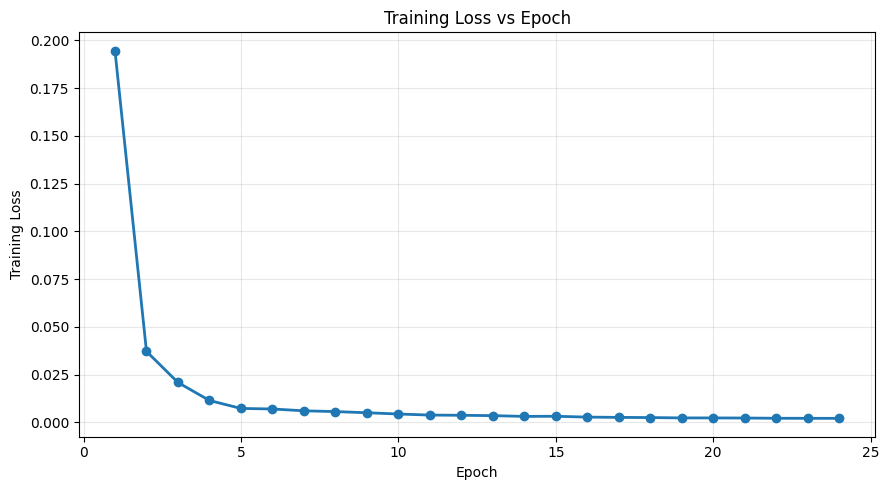

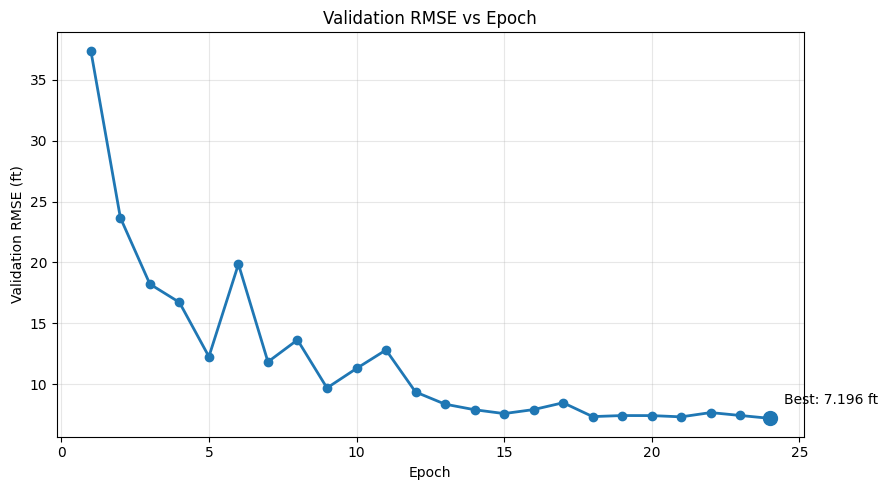

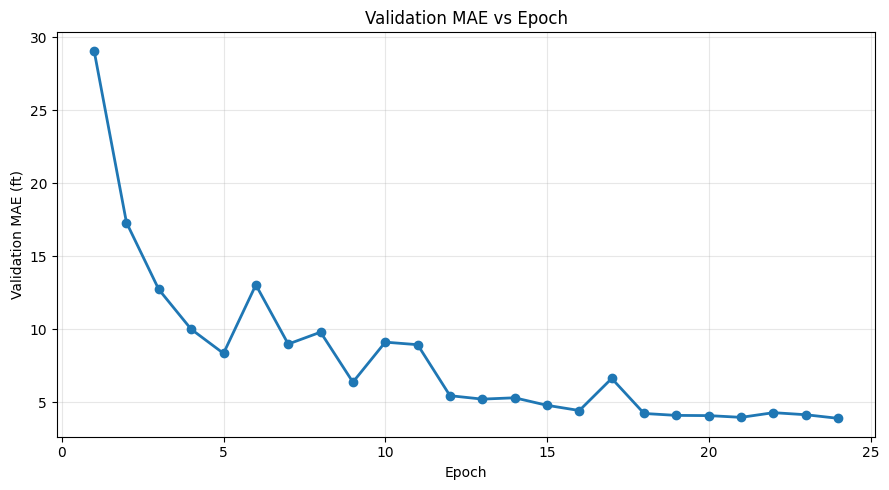


Running test inference...

No local post-PS TVT available for sanity-check plots.

Generating geological diagnostics...
No local true TVT is available for a True vs Predicted plot.
No local true TVT is available for an error plot.
No local true TVT available for scatter plot.


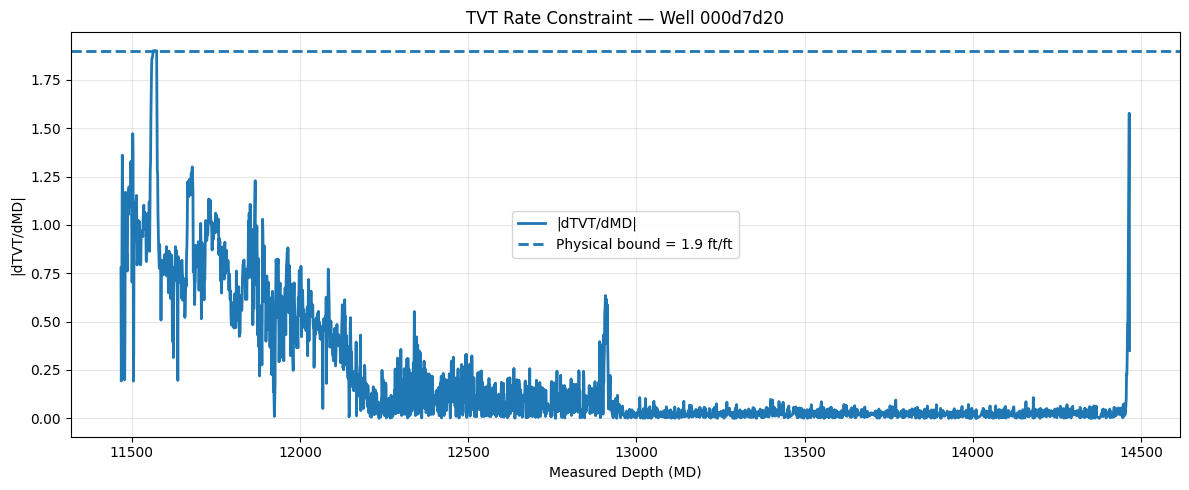

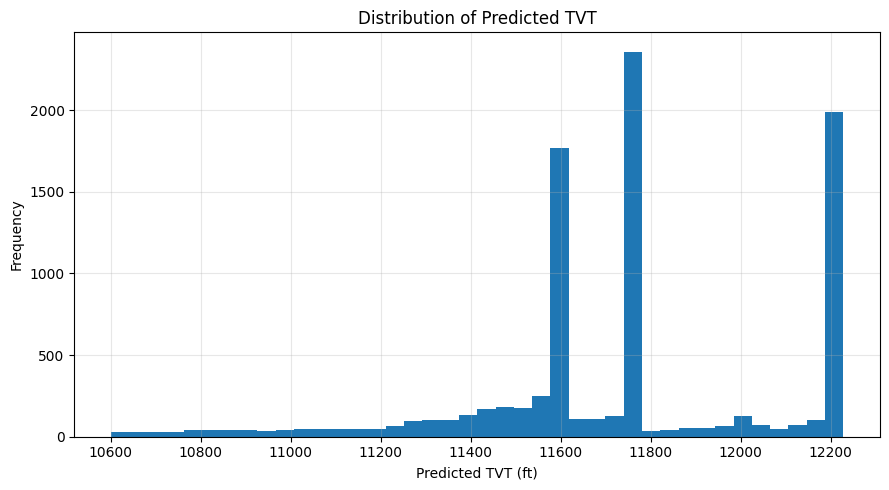


Building submission...
sample_submission.csv columns: ['id', 'tvt']
              id  tvt
0  000d7d20_1442  0.0
1  000d7d20_1443  0.0
2  000d7d20_1444  0.0
3  000d7d20_1445  0.0
4  000d7d20_1446  0.0

Wrote 14151 rows to /kaggle/working/submission.csv

Submission preview:
              id  tvt
0  000d7d20_1442  0.0
1  000d7d20_1443  0.0
2  000d7d20_1444  0.0
3  000d7d20_1445  0.0
4  000d7d20_1446  0.0

DONE.


In [14]:
# ================================================================
# ROGII - Wellbore Geology Prediction
# Cross-Attention Deep Model + Training/Validation Diagnostics
# ================================================================

import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import re
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ================================================================
# 0. CONFIGURATION
# ================================================================

COMP_DIR = "/kaggle/input/competitions/rogii-wellbore-geology-prediction"

TRAIN_DIR = os.path.join(COMP_DIR, "train")
TEST_DIR = os.path.join(COMP_DIR, "test")

SAMPLE_SUB_PATH = os.path.join(
    COMP_DIR,
    "sample_submission.csv"
)

OUTPUT_SUBMISSION = "/kaggle/working/submission.csv"
BEST_MODEL_PATH = "/kaggle/working/best_model.pt"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

# Model
HIDDEN = 64
N_HEADS = 4

# Physical constraint
RATE_BOUND = 1.9
SMOOTH_LOSS_WEIGHT = 0.05

# Sequence limits
MAX_TW_LEN = 1000
MAX_HW_LEN = 3000

# Training
BATCH_SIZE = 1
EPOCHS = 24
LR = 3e-4

VAL_FRACTION = 0.12
RANDOM_STATE = 0

WELL_ID_RE = re.compile(
    r"^([0-9a-f]{8})[_\-]?(.*)$"
)


# ================================================================
# 1. DISCOVER WELLS
# ================================================================

def discover_wells(data_dir):

    horiz_files = sorted(
        glob.glob(
            os.path.join(
                data_dir,
                "*horizontal_well*.csv"
            )
        )
    )

    typewell_files = sorted(
        glob.glob(
            os.path.join(
                data_dir,
                "*typewell*.csv"
            )
        )
    )

    def wid_from(path):

        filename = os.path.basename(path)

        m = re.match(
            r"([0-9a-f]{8})__",
            filename
        )

        return m.group(1) if m else None

    typewell_map = {
        wid_from(tp): tp
        for tp in typewell_files
        if wid_from(tp)
    }

    pairs = []

    for hf in horiz_files:

        wid = wid_from(hf)

        tp = typewell_map.get(wid)

        if wid is None or tp is None:
            continue

        pairs.append(
            (wid, hf, tp)
        )

    print(
        f"{data_dir}: {len(pairs)} well pairs"
    )

    return pairs


# ================================================================
# 2. DATASET
# ================================================================

class WellDataset(Dataset):

    def __init__(self, pairs, is_train):

        self.pairs = pairs
        self.is_train = is_train

    def __len__(self):

        return len(self.pairs)

    def __getitem__(self, idx):

        wid, hf, tf = self.pairs[idx]

        # --------------------------------------------------------
        # Horizontal well
        # --------------------------------------------------------

        h = pd.read_csv(hf)

        h = (
            h.sort_values("MD")
             .reset_index(drop=True)
        )

        # Limit sequence length -- TRAIN ONLY. At test/inference time we
        # must keep every row, since row_idx in the submission id refers
        # to the full, untruncated well and truncating here silently
        # drops predictions for anything past MAX_HW_LEN.
        if self.is_train:
            h = (
                h.iloc[:MAX_HW_LEN]
                 .reset_index(drop=True)
            )

        # --------------------------------------------------------
        # Typewell
        # --------------------------------------------------------

        t = pd.read_csv(tf)

        # --------------------------------------------------------
        # Horizontal GR
        # --------------------------------------------------------

        gr = h["GR"].values.astype(
            np.float32
        )

        gr_missing = np.isnan(gr).astype(
            np.float32
        )

        gr_filled = (
            pd.Series(gr)
            .interpolate(
                limit_direction="both"
            )
            .fillna(0)
            .values
            .astype(np.float32)
        )

        # --------------------------------------------------------
        # Labels / known TVT
        # --------------------------------------------------------

        labeled = (
            h["TVT_input"]
            .notna()
            .values
        )

        md = h["MD"].values.astype(
            np.float32
        )

        if labeled.any():

            anchor_end_md = md[labeled].max()

        else:

            anchor_end_md = md.min()

        dist_from_ps = np.clip(
            md - anchor_end_md,
            0,
            None
        ).astype(np.float32)

        # --------------------------------------------------------
        # Coordinates
        # --------------------------------------------------------

        x = h["X"].values.astype(
            np.float32
        )

        y = h["Y"].values.astype(
            np.float32
        )

        z = h["Z"].values.astype(
            np.float32
        )

        dx = np.diff(
            x,
            prepend=x[0]
        ).astype(np.float32)

        dy = np.diff(
            y,
            prepend=y[0]
        ).astype(np.float32)

        dz = np.diff(
            z,
            prepend=z[0]
        ).astype(np.float32)

        # --------------------------------------------------------
        # TVT anchor
        # --------------------------------------------------------

        tvt_input = (
            h["TVT_input"]
            .values
            .astype(np.float32)
        )

        anchor_val = np.nan_to_num(
            tvt_input,
            nan=0.0
        ).astype(np.float32)

        anchor_flag = labeled.astype(
            np.float32
        )

        # --------------------------------------------------------
        # Normalization
        # --------------------------------------------------------

        norm_ref = anchor_val[
            anchor_flag.astype(bool)
        ]

        if len(norm_ref):

            norm_mean = float(
                norm_ref.mean()
            )

        else:

            norm_mean = float(
                np.nanmean(tvt_input)
            )

        if len(norm_ref) > 1:

            norm_std = float(
                norm_ref.std()
            )

        else:

            norm_std = 1.0

        if norm_std <= 1e-6:

            norm_std = 1.0

        # --------------------------------------------------------
        # Horizontal well features
        # --------------------------------------------------------

        hw_feats = np.stack(
            [

                (
                    gr_filled
                    - np.nanmean(gr_filled)
                )
                /
                (
                    np.nanstd(gr_filled)
                    + 1e-6
                ),

                gr_missing,

                dx / 10.0,

                dy / 10.0,

                dz / 10.0,

                dist_from_ps / 1000.0,

                (
                    anchor_val
                    - norm_mean
                )
                /
                norm_std,

                anchor_flag

            ],
            axis=1
        ).astype(np.float32)

        # --------------------------------------------------------
        # Typewell features
        # --------------------------------------------------------

        tw_gr = t["GR"].values.astype(
            np.float32
        )

        tw_gr = (
            tw_gr
            - np.nanmean(tw_gr)
        ) / (
            np.nanstd(tw_gr)
            + 1e-6
        )

        tw_gr = np.nan_to_num(
            tw_gr,
            nan=0.0
        )

        tw_tvt_raw = t["TVT"].values.astype(
            np.float32
        )

        tw_tvt_norm = (
            tw_tvt_raw
            - norm_mean
        ) / norm_std

        tw_feats = np.stack(
            [tw_gr],
            axis=1
        ).astype(np.float32)

        # --------------------------------------------------------
        # Target
        # --------------------------------------------------------

        if "TVT" in h.columns:

            target_norm = (
                h["TVT"]
                .values
                .astype(np.float32)
                - norm_mean
            ) / norm_std

            true_tvt_raw = (
                h["TVT"]
                .values
                .astype(np.float32)
            )

        else:

            target_norm = np.zeros(
                len(h),
                dtype=np.float32
            )

            true_tvt_raw = np.full(
                len(h),
                np.nan,
                dtype=np.float32
            )

        return {

            "well_id": wid,

            "md": md,

            "hw_feats": hw_feats,

            "tw_feats": tw_feats,

            "tw_tvt_norm":
                tw_tvt_norm.astype(
                    np.float32
                ),

            "target_norm":
                target_norm,

            "labeled":
                labeled,

            "norm_mean":
                norm_mean,

            "norm_std":
                norm_std,

            "true_tvt_raw":
                true_tvt_raw
        }


# ================================================================
# 3. COLLATE
# ================================================================

def collate(batch):

    B = len(batch)

    hw_len = max(
        len(b["hw_feats"])
        for b in batch
    )

    tw_len = max(
        len(b["tw_feats"])
        for b in batch
    )

    hw_dim = batch[0][
        "hw_feats"
    ].shape[1]

    tw_dim = batch[0][
        "tw_feats"
    ].shape[1]

    hw = torch.zeros(
        B,
        hw_len,
        hw_dim
    )

    tw = torch.zeros(
        B,
        tw_len,
        tw_dim
    )

    tw_tvt = torch.zeros(
        B,
        tw_len
    )

    target = torch.zeros(
        B,
        hw_len
    )

    hw_mask = torch.zeros(
        B,
        hw_len,
        dtype=torch.bool
    )

    tw_mask = torch.zeros(
        B,
        tw_len,
        dtype=torch.bool
    )

    labeled_mask = torch.zeros(
        B,
        hw_len,
        dtype=torch.bool
    )

    md = torch.zeros(
        B,
        hw_len
    )

    norm_mean = torch.zeros(B)

    norm_std = torch.zeros(B)

    true_tvt_raw = torch.full(
        (B, hw_len),
        float("nan")
    )

    for i, b in enumerate(batch):

        L = len(
            b["hw_feats"]
        )

        T = len(
            b["tw_feats"]
        )

        hw[i, :L] = torch.from_numpy(
            b["hw_feats"]
        )

        tw[i, :T] = torch.from_numpy(
            b["tw_feats"]
        )

        tw_tvt[i, :T] = torch.from_numpy(
            b["tw_tvt_norm"]
        )

        target[i, :L] = torch.from_numpy(
            b["target_norm"]
        )

        hw_mask[i, :L] = True

        tw_mask[i, :T] = True

        labeled_mask[i, :L] = torch.from_numpy(
            b["labeled"]
        )

        md[i, :L] = torch.from_numpy(
            b["md"]
        )

        norm_mean[i] = b[
            "norm_mean"
        ]

        norm_std[i] = b[
            "norm_std"
        ]

        true_tvt_raw[i, :L] = torch.from_numpy(
            b["true_tvt_raw"]
        )

    return {

        "well_id":
            [b["well_id"] for b in batch],

        "hw": hw,

        "tw": tw,

        "tw_tvt": tw_tvt,

        "target": target,

        "hw_mask": hw_mask,

        "tw_mask": tw_mask,

        "labeled_mask":
            labeled_mask,

        "md": md,

        "norm_mean":
            norm_mean,

        "norm_std":
            norm_std,

        "true_tvt_raw":
            true_tvt_raw
    }


# ================================================================
# 4. CROSS-ATTENTION MODEL
# ================================================================

class CrossAttnTVTModel(nn.Module):

    def __init__(
        self,
        hw_dim,
        tw_dim,
        hidden=HIDDEN,
        n_heads=N_HEADS
    ):

        super().__init__()

        # Horizontal well encoder
        self.hw_encoder = nn.GRU(
            hw_dim,
            hidden,
            batch_first=True,
            bidirectional=True
        )

        # Typewell encoder
        self.tw_encoder = nn.GRU(
            tw_dim,
            hidden,
            batch_first=True,
            bidirectional=True
        )

        # Projection
        self.hw_proj = nn.Linear(
            hidden * 2,
            hidden
        )

        self.tw_proj = nn.Linear(
            hidden * 2,
            hidden
        )

        # Cross attention
        self.cross_attn = nn.MultiheadAttention(
            hidden,
            n_heads,
            batch_first=True
        )

        # Prediction head
        self.head = nn.Sequential(

            nn.Linear(
                hidden * 2 + 1,
                hidden
            ),

            nn.ReLU(),

            nn.Linear(
                hidden,
                hidden // 2
            ),

            nn.ReLU(),

            nn.Linear(
                hidden // 2,
                1
            )
        )

    def forward(
        self,
        hw,
        tw,
        tw_tvt,
        hw_mask,
        tw_mask
    ):

        # --------------------------------------------------------
        # Encode horizontal well
        # --------------------------------------------------------

        hw_h, _ = self.hw_encoder(
            hw
        )

        # --------------------------------------------------------
        # Encode typewell
        # --------------------------------------------------------

        tw_h, _ = self.tw_encoder(
            tw
        )

        # --------------------------------------------------------
        # Project
        # --------------------------------------------------------

        q = self.hw_proj(
            hw_h
        )

        k = self.tw_proj(
            tw_h
        )

        # --------------------------------------------------------
        # Cross attention
        # --------------------------------------------------------

        key_padding_mask = ~tw_mask

        context, attn_weights = (
            self.cross_attn(
                q,
                k,
                k,
                key_padding_mask=
                    key_padding_mask,
                need_weights=True,
                average_attn_weights=True
            )
        )

        # --------------------------------------------------------
        # Soft TVT read-off
        # --------------------------------------------------------

        coarse_tvt = torch.bmm(
            attn_weights,
            tw_tvt.unsqueeze(-1)
        ).squeeze(-1)

        # --------------------------------------------------------
        # Residual correction
        # --------------------------------------------------------

        combined = torch.cat(
            [
                q,
                context,
                coarse_tvt.unsqueeze(-1)
            ],
            dim=-1
        )

        residual = self.head(
            combined
        ).squeeze(-1)

        # Final prediction
        pred = (
            coarse_tvt
            + residual
        )

        return (
            pred,
            coarse_tvt,
            attn_weights
        )


# ================================================================
# 5. LOSS
# ================================================================

def compute_loss(
    pred,
    target,
    md,
    mask,
    norm_std,
    rate_bound=RATE_BOUND,
    smooth_w=SMOOTH_LOSS_WEIGHT
):

    # ------------------------------------------------------------
    # Data loss
    # ------------------------------------------------------------

    diff = (
        pred - target
    ) ** 2

    diff = diff * mask

    data_loss = (
        diff.sum()
        /
        mask.sum().clamp(min=1)
    )

    # ------------------------------------------------------------
    # Physical smoothness constraint
    # ------------------------------------------------------------

    pred_raw = (
        pred
        *
        norm_std.unsqueeze(1)
    )

    d_pred = (
        pred_raw[:, 1:]
        -
        pred_raw[:, :-1]
    )

    d_md = (
        md[:, 1:]
        -
        md[:, :-1]
    )

    d_md = d_md.clamp(
        min=1e-3
    )

    rate = (
        d_pred / d_md
    )

    excess = F.relu(
        rate.abs()
        -
        rate_bound
    )

    pair_mask = (
        mask[:, 1:]
        *
        mask[:, :-1]
    )

    smooth_loss = (
        (excess * pair_mask).sum()
        /
        pair_mask.sum().clamp(min=1)
    )

    total_loss = (
        data_loss
        +
        smooth_w * smooth_loss
    )

    return (
        total_loss,
        data_loss.item(),
        smooth_loss.item()
    )


# ================================================================
# 6. TRAINING HISTORY
# ================================================================

history = {

    "epoch": [],

    "train_loss": [],

    "val_rmse": [],

    "val_mae": []
}


# ================================================================
# 7. TRAIN MODEL
# ================================================================

def train_model(train_pairs):

    rng = np.random.RandomState(
        RANDOM_STATE
    )

    idx = rng.permutation(
        len(train_pairs)
    )

    n_val = max(
        1,
        int(
            len(train_pairs)
            * VAL_FRACTION
        )
    )

    val_idx = idx[:n_val]

    tr_idx = idx[n_val:]

    tr_pairs = [
        train_pairs[i]
        for i in tr_idx
    ]

    val_pairs = [
        train_pairs[i]
        for i in val_idx
    ]

    print(
        f"Train wells: {len(tr_pairs)} "
        f"| Val wells: {len(val_pairs)}"
    )

    # ------------------------------------------------------------
    # Datasets
    # ------------------------------------------------------------

    tr_ds = WellDataset(
        tr_pairs,
        is_train=True
    )

    val_ds = WellDataset(
        val_pairs,
        is_train=True
    )

    tr_loader = DataLoader(
        tr_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate,
        num_workers=2
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate,
        num_workers=2
    )

    # ------------------------------------------------------------
    # Model
    # ------------------------------------------------------------

    hw_dim = tr_ds[0][
        "hw_feats"
    ].shape[1]

    tw_dim = tr_ds[0][
        "tw_feats"
    ].shape[1]

    model = CrossAttnTVTModel(
        hw_dim,
        tw_dim
    ).to(DEVICE)

    # ------------------------------------------------------------
    # Optimizer
    # ------------------------------------------------------------

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-5
    )

    sched = (
        torch.optim.lr_scheduler
        .CosineAnnealingLR(
            opt,
            T_max=EPOCHS
        )
    )

    best_val_rmse = float(
        "inf"
    )

    # ------------------------------------------------------------
    # Training
    # ------------------------------------------------------------

    for epoch in range(EPOCHS):

        model.train()

        tr_loss_sum = 0.0

        n_batches = 0

        # ========================================================
        # TRAIN
        # ========================================================

        for batch in tr_loader:

            hw = batch["hw"].to(
                DEVICE
            )

            tw = batch["tw"].to(
                DEVICE
            )

            tw_tvt = batch[
                "tw_tvt"
            ].to(DEVICE)

            target = batch[
                "target"
            ].to(DEVICE)

            hw_mask = batch[
                "hw_mask"
            ].to(DEVICE)

            tw_mask = batch[
                "tw_mask"
            ].to(DEVICE)

            md = batch[
                "md"
            ].to(DEVICE)

            norm_std = batch[
                "norm_std"
            ].to(DEVICE)

            # Forward
            pred, coarse, _ = model(
                hw,
                tw,
                tw_tvt,
                hw_mask,
                tw_mask
            )

            # Loss
            loss, dloss, sloss = (
                compute_loss(
                    pred,
                    target,
                    md,
                    hw_mask.float(),
                    norm_std
                )
            )

            # Backprop
            opt.zero_grad()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            opt.step()

            tr_loss_sum += (
                loss.item()
            )

            n_batches += 1

        # Learning-rate schedule
        sched.step()

        avg_train_loss = (
            tr_loss_sum
            /
            n_batches
        )

        # ========================================================
        # VALIDATION
        # ========================================================

        model.eval()

        val_preds_raw = []

        val_targets_raw = []

        with torch.no_grad():

            for batch in val_loader:

                hw = batch[
                    "hw"
                ].to(DEVICE)

                tw = batch[
                    "tw"
                ].to(DEVICE)

                tw_tvt = batch[
                    "tw_tvt"
                ].to(DEVICE)

                hw_mask = batch[
                    "hw_mask"
                ].to(DEVICE)

                tw_mask = batch[
                    "tw_mask"
                ].to(DEVICE)

                pred, _, _ = model(
                    hw,
                    tw,
                    tw_tvt,
                    hw_mask,
                    tw_mask
                )

                # De-normalize
                pred_raw = (
                    pred.cpu().numpy()
                    *
                    batch[
                        "norm_std"
                    ].numpy()[:, None]
                    +
                    batch[
                        "norm_mean"
                    ].numpy()[:, None]
                )

                mask_np = batch[
                    "hw_mask"
                ].numpy()

                true_raw = batch[
                    "true_tvt_raw"
                ].numpy()

                for i in range(
                    pred_raw.shape[0]
                ):

                    m = (
                        mask_np[i]
                        &
                        ~np.isnan(
                            true_raw[i]
                        )
                    )

                    val_preds_raw.append(
                        pred_raw[i][m]
                    )

                    val_targets_raw.append(
                        true_raw[i][m]
                    )

        # --------------------------------------------------------
        # Metrics
        # --------------------------------------------------------

        val_preds_raw = np.concatenate(
            val_preds_raw
        )

        val_targets_raw = np.concatenate(
            val_targets_raw
        )

        val_rmse = math.sqrt(
            mean_squared_error(
                val_targets_raw,
                val_preds_raw
            )
        )

        val_mae = mean_absolute_error(
            val_targets_raw,
            val_preds_raw
        )

        # --------------------------------------------------------
        # SAVE HISTORY
        # --------------------------------------------------------

        history["epoch"].append(
            epoch + 1
        )

        history["train_loss"].append(
            avg_train_loss
        )

        history["val_rmse"].append(
            val_rmse
        )

        history["val_mae"].append(
            val_mae
        )

        # --------------------------------------------------------
        # Print
        # --------------------------------------------------------

        print(
            f"Epoch {epoch+1}/{EPOCHS} "
            f"| train_loss={avg_train_loss:.4f} "
            f"| val_RMSE={val_rmse:.3f} ft "
            f"| val_MAE={val_mae:.3f} ft"
        )

        # --------------------------------------------------------
        # Save best model
        # --------------------------------------------------------

        if val_rmse < best_val_rmse:

            best_val_rmse = val_rmse

            torch.save(
                model.state_dict(),
                BEST_MODEL_PATH
            )

            print(
                f"  -> Best model saved "
                f"(RMSE={best_val_rmse:.3f} ft)"
            )

    # ------------------------------------------------------------
    # Load best model
    # ------------------------------------------------------------

    model.load_state_dict(
        torch.load(
            BEST_MODEL_PATH,
            map_location=DEVICE
        )
    )

    print(
        "\nBest validation RMSE:",
        f"{best_val_rmse:.3f} ft"
    )

    return model


# ================================================================
# 8. TRAINING PLOTS
# ================================================================

def plot_training_history():

    # ------------------------------------------------------------
    # Plot 1: Training Loss
    # ------------------------------------------------------------

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        history["epoch"],
        history["train_loss"],
        marker="o",
        linewidth=2
    )

    plt.xlabel("Epoch")

    plt.ylabel("Training Loss")

    plt.title(
        "Training Loss vs Epoch"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

    # ------------------------------------------------------------
    # Plot 2: Validation RMSE
    # ------------------------------------------------------------

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        history["epoch"],
        history["val_rmse"],
        marker="o",
        linewidth=2
    )

    best_idx = np.argmin(
        history["val_rmse"]
    )

    best_epoch = (
        history["epoch"][best_idx]
    )

    best_rmse = (
        history["val_rmse"][best_idx]
    )

    plt.scatter(
        best_epoch,
        best_rmse,
        s=100,
        zorder=5
    )

    plt.annotate(
        f"Best: {best_rmse:.3f} ft",
        (
            best_epoch,
            best_rmse
        ),
        xytext=(10, 10),
        textcoords="offset points"
    )

    plt.xlabel("Epoch")

    plt.ylabel(
        "Validation RMSE (ft)"
    )

    plt.title(
        "Validation RMSE vs Epoch"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

    # ------------------------------------------------------------
    # Plot 3: Validation MAE
    # ------------------------------------------------------------

    plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        history["epoch"],
        history["val_mae"],
        marker="o",
        linewidth=2
    )

    plt.xlabel("Epoch")

    plt.ylabel(
        "Validation MAE (ft)"
    )

    plt.title(
        "Validation MAE vs Epoch"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 9. TEST PREDICTION
# ================================================================

def predict_test(
    model,
    test_pairs
):

    ds = WellDataset(
        test_pairs,
        is_train=False
    )

    loader = DataLoader(
        ds,
        batch_size=1,
        shuffle=False,
        collate_fn=collate,
        num_workers=2
    )

    model.eval()

    rows = []

    with torch.no_grad():

        for batch in loader:

            hw = batch[
                "hw"
            ].to(DEVICE)

            tw = batch[
                "tw"
            ].to(DEVICE)

            tw_tvt = batch[
                "tw_tvt"
            ].to(DEVICE)

            hw_mask = batch[
                "hw_mask"
            ].to(DEVICE)

            tw_mask = batch[
                "tw_mask"
            ].to(DEVICE)

            pred, coarse, attn = model(
                hw,
                tw,
                tw_tvt,
                hw_mask,
                tw_mask
            )

            # De-normalize
            pred_raw = (
                pred.cpu().numpy()
                *
                batch[
                    "norm_std"
                ].numpy()[:, None]
                +
                batch[
                    "norm_mean"
                ].numpy()[:, None]
            )[0]

            wid = batch[
                "well_id"
            ][0]

            md = batch[
                "md"
            ][0].numpy()

            mask = batch[
                "hw_mask"
            ][0].numpy()

            labeled = batch[
                "labeled_mask"
            ][0].numpy()

            true_raw = batch[
                "true_tvt_raw"
            ][0].numpy()

            for j in range(
                int(mask.sum())
            ):

                rows.append(
                    {

                        "well_id":
                            wid,

                        "row_idx":
                            j,

                        "MD":
                            md[j],

                        "pred":
                            pred_raw[j],

                        "labeled":
                            bool(
                                labeled[j]
                            ),

                        "true_tvt_local":
                            true_raw[j]
                    }
                )

    return pd.DataFrame(rows)


# ================================================================
# 10. ENFORCE PHYSICAL RATE BOUND
# ================================================================

def enforce_rate_bound_df(
    df,
    rate_bound=RATE_BOUND
):

    out = []

    for wid, g in df.groupby(
        "well_id",
        sort=False
    ):

        g = (
            g.sort_values("MD")
             .copy()
        )

        vals = g[
            "pred"
        ].values.copy()

        mdv = g[
            "MD"
        ].values

        for i in range(
            1,
            len(vals)
        ):

            d_md = (
                mdv[i]
                -
                mdv[i - 1]
            )

            max_step = (
                rate_bound
                *
                max(d_md, 0)
            )

            delta = (
                vals[i]
                -
                vals[i - 1]
            )

            if (
                max_step > 0
                and
                abs(delta) > max_step
            ):

                vals[i] = (
                    vals[i - 1]
                    +
                    np.sign(delta)
                    *
                    max_step
                )

        g[
            "pred_smoothed"
        ] = vals

        out.append(g)

    return pd.concat(
        out,
        ignore_index=True
    )


# ================================================================
# 11. GEOLOGICAL PLOT:
#     TRUE TVT VS PREDICTED TVT
# ================================================================

def plot_true_vs_predicted(
    pred_df
):

    plot_df = pred_df[
        pred_df[
            "true_tvt_local"
        ].notna()
    ].copy()

    if len(plot_df) == 0:

        print(
            "No local true TVT is available "
            "for a True vs Predicted plot."
        )

        return

    # Select first available well
    well_id = (
        plot_df[
            "well_id"
        ].iloc[0]
    )

    g = (
        plot_df[
            plot_df["well_id"]
            == well_id
        ]
        .sort_values("MD")
    )

    plt.figure(
        figsize=(12, 6)
    )

    plt.plot(
        g["MD"],
        g["true_tvt_local"],
        label="True TVT",
        linewidth=2
    )

    plt.plot(
        g["MD"],
        g["pred_smoothed"],
        label="Predicted TVT",
        linewidth=2
    )

    plt.xlabel(
        "Measured Depth (MD)"
    )

    plt.ylabel(
        "TVT (ft)"
    )

    plt.title(
        f"True vs Predicted TVT — Well {well_id}"
    )

    plt.legend()

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 12. ERROR VS MEASURED DEPTH
# ================================================================

def plot_error_vs_md(
    pred_df
):

    plot_df = pred_df[
        pred_df[
            "true_tvt_local"
        ].notna()
    ].copy()

    if len(plot_df) == 0:

        print(
            "No local true TVT is available "
            "for an error plot."
        )

        return

    plot_df["error"] = (
        plot_df["pred_smoothed"]
        -
        plot_df["true_tvt_local"]
    )

    plt.figure(
        figsize=(12, 5)
    )

    plt.scatter(
        plot_df["MD"],
        plot_df["error"],
        s=12,
        alpha=0.7
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1.5
    )

    plt.xlabel(
        "Measured Depth (MD)"
    )

    plt.ylabel(
        "Prediction Error (ft)"
    )

    plt.title(
        "TVT Prediction Error vs Measured Depth"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 13. PHYSICAL CONSTRAINT PLOT
# ================================================================

def plot_rate_constraint(
    pred_df
):

    # We can use predictions even without true TVT
    if len(pred_df) == 0:

        print(
            "No predictions available."
        )

        return

    well_id = pred_df[
        "well_id"
    ].iloc[0]

    g = (
        pred_df[
            pred_df["well_id"]
            == well_id
        ]
        .sort_values("MD")
        .copy()
    )

    g["dTVT_dMD"] = (
        g["pred_smoothed"].diff()
        /
        g["MD"].diff()
    )

    plt.figure(
        figsize=(12, 5)
    )

    plt.plot(
        g["MD"],
        g["dTVT_dMD"].abs(),
        linewidth=2,
        label="|dTVT/dMD|"
    )

    plt.axhline(
        RATE_BOUND,
        linestyle="--",
        linewidth=2,
        label=f"Physical bound = {RATE_BOUND} ft/ft"
    )

    plt.xlabel(
        "Measured Depth (MD)"
    )

    plt.ylabel(
        "|dTVT/dMD|"
    )

    plt.title(
        f"TVT Rate Constraint — Well {well_id}"
    )

    plt.legend()

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 14. PREDICTION DISTRIBUTION
# ================================================================

def plot_prediction_distribution(
    pred_df
):

    if len(pred_df) == 0:

        return

    plt.figure(
        figsize=(9, 5)
    )

    plt.hist(
        pred_df[
            "pred_smoothed"
        ],
        bins=40
    )

    plt.xlabel(
        "Predicted TVT (ft)"
    )

    plt.ylabel(
        "Frequency"
    )

    plt.title(
        "Distribution of Predicted TVT"
    )

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 15. TRUE VS PREDICTED SCATTER
# ================================================================

def plot_true_pred_scatter(
    pred_df
):

    plot_df = pred_df[
        pred_df[
            "true_tvt_local"
        ].notna()
    ].copy()

    if len(plot_df) == 0:

        print(
            "No local true TVT available "
            "for scatter plot."
        )

        return

    y_true = plot_df[
        "true_tvt_local"
    ].values

    y_pred = plot_df[
        "pred_smoothed"
    ].values

    rmse = math.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    plt.figure(
        figsize=(7, 7)
    )

    plt.scatter(
        y_true,
        y_pred,
        s=15,
        alpha=0.6
    )

    min_val = min(
        y_true.min(),
        y_pred.min()
    )

    max_val = max(
        y_true.max(),
        y_pred.max()
    )

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        linewidth=2,
        label="Perfect prediction"
    )

    plt.xlabel(
        "True TVT (ft)"
    )

    plt.ylabel(
        "Predicted TVT (ft)"
    )

    plt.title(
        f"True vs Predicted TVT\n"
        f"RMSE = {rmse:.3f} ft | "
        f"MAE = {mae:.3f} ft"
    )

    plt.legend()

    plt.grid(
        True,
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# 16. SUBMISSION
# ================================================================

def build_submission(
    pred_df,
    sample_sub_path=SAMPLE_SUB_PATH
):

    sub_template = pd.read_csv(
        sample_sub_path
    )

    print(
        "sample_submission.csv columns:",
        sub_template.columns.tolist()
    )

    print(
        sub_template.head()
    )

    id_col = (
        sub_template.columns[0]
    )

    target_cols = [
        c
        for c in sub_template.columns
        if c != id_col
    ]

    target_col = (
        target_cols[0]
        if target_cols
        else "TVT"
    )

    parsed = (
        sub_template[id_col]
        .astype(str)
        .str.extract(WELL_ID_RE)
    )

    parsed.columns = [
        "well_id",
        "md_str"
    ]

    sub_template[
        "well_id"
    ] = parsed["well_id"]

    sub_template[
        "row_idx"
    ] = pd.to_numeric(
        parsed["md_str"],
        errors="coerce"
    )

    n_unparsed = (
        sub_template[
            "well_id"
        ].isna().sum()
    )

    if n_unparsed > 0:

        print(
            f"WARNING: "
            f"{n_unparsed}/"
            f"{len(sub_template)} "
            f"ids failed to parse."
        )

    pred_df = pred_df.copy()

    merged = sub_template.merge(
        pred_df[
            [
                "well_id",
                "row_idx",
                "pred_smoothed"
            ]
        ],
        on=[
            "well_id",
            "row_idx"
        ],
        how="left"
    )

    n_missing = (
        merged[
            "pred_smoothed"
        ].isna().sum()
    )

    if n_missing > 0:

        print(
            f"WARNING: "
            f"{n_missing}/"
            f"{len(merged)} rows unmatched."
        )

        merged[
            "pred_smoothed"
        ] = merged[
            "pred_smoothed"
        ].fillna(
            merged[target_col]
        )

    final = sub_template[
        [id_col]
    ].copy()

    final[
        target_col
    ] = merged[
        "pred_smoothed"
    ].values

    return final


# ================================================================
# 17. MAIN
# ================================================================

if __name__ == "__main__":

    print("=" * 70)
    print("ROGII Cross-Attention TVT Prediction")
    print("=" * 70)

    # ------------------------------------------------------------
    # Discover wells
    # ------------------------------------------------------------

    print("\nDiscovering training wells...")

    train_pairs = discover_wells(
        TRAIN_DIR
    )

    print("\nDiscovering test wells...")

    test_pairs = discover_wells(
        TEST_DIR
    )

    if (
        not train_pairs
        or
        not test_pairs
    ):

        raise SystemExit(
            "No wells found -- check dataset paths."
        )

    print(
        f"\nTraining wells: "
        f"{len(train_pairs)}"
    )

    print(
        f"Test wells: "
        f"{len(test_pairs)}"
    )

    # ------------------------------------------------------------
    # Train
    # ------------------------------------------------------------

    print("\nStarting training...\n")

    model = train_model(
        train_pairs
    )

    # ------------------------------------------------------------
    # IMPORTANT TRAINING PLOTS
    # ------------------------------------------------------------

    print(
        "\nGenerating training plots..."
    )

    plot_training_history()

    # ------------------------------------------------------------
    # Test prediction
    # ------------------------------------------------------------

    print(
        "\nRunning test inference..."
    )

    pred_df = predict_test(
        model,
        test_pairs
    )

    # ------------------------------------------------------------
    # Physical smoothing
    # ------------------------------------------------------------

    pred_df = enforce_rate_bound_df(
        pred_df
    )

    # ------------------------------------------------------------
    # Local sanity check
    # ------------------------------------------------------------

    local_check = pred_df[
        (~pred_df["labeled"])
        &
        pred_df[
            "true_tvt_local"
        ].notna()
    ]

    if len(local_check) > 0:

        local_rmse = math.sqrt(
            mean_squared_error(
                local_check[
                    "true_tvt_local"
                ],
                local_check[
                    "pred_smoothed"
                ]
            )
        )

        local_mae = mean_absolute_error(
            local_check[
                "true_tvt_local"
            ],
            local_check[
                "pred_smoothed"
            ]
        )

        print(
            "\n"
            + "=" * 70
        )

        print(
            "LOCAL SANITY CHECK"
        )

        print(
            "=" * 70
        )

        print(
            f"Post-PS RMSE: "
            f"{local_rmse:.3f} ft"
        )

        print(
            f"Post-PS MAE: "
            f"{local_mae:.3f} ft"
        )

        print(
            f"Number of points: "
            f"{len(local_check)}"
        )

        print(
            "NOTE: This is NOT the official competition score."
        )

        print(
            "=" * 70
        )

    else:

        print(
            "\nNo local post-PS TVT available "
            "for sanity-check plots."
        )

    # ------------------------------------------------------------
    # IMPORTANT GEOLOGICAL PLOTS
    # ------------------------------------------------------------

    print(
        "\nGenerating geological diagnostics..."
    )

    # 1. True vs predicted trajectory
    plot_true_vs_predicted(
        pred_df
    )

    # 2. Prediction error vs MD
    plot_error_vs_md(
        pred_df
    )

    # 3. True vs predicted scatter
    plot_true_pred_scatter(
        pred_df
    )

    # 4. Physical rate constraint
    plot_rate_constraint(
        pred_df
    )

    # 5. Prediction distribution
    plot_prediction_distribution(
        pred_df
    )

    # ------------------------------------------------------------
    # Build submission
    # ------------------------------------------------------------

    print(
        "\nBuilding submission..."
    )

    submission = build_submission(
        pred_df
    )

    submission.to_csv(
        OUTPUT_SUBMISSION,
        index=False
    )

    print(
        f"\nWrote "
        f"{len(submission)} rows to "
        f"{OUTPUT_SUBMISSION}"
    )

    print(
        "\nSubmission preview:"
    )

    print(
        submission.head()
    )

    print(
        "\nDONE."
    )